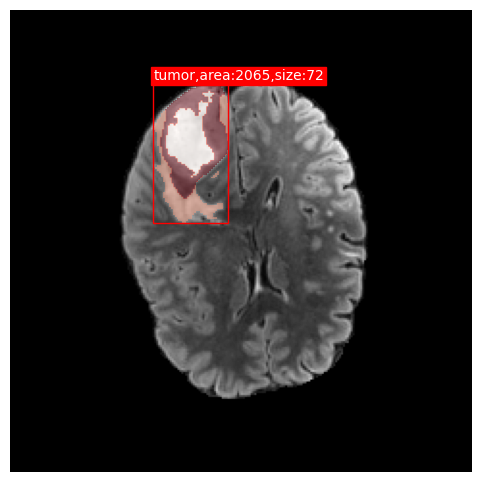

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nb
import matplotlib.patches as patches

img_path = "BraTS2021_00495/BraTS2021_00495_flair.nii.gz"
seg_path = "BraTS2021_00495/BraTS2021_00495_seg.nii.gz"

img = nb.load(img_path)
seg = nb.load(seg_path)
imgd = np.asarray(img.get_fdata())
segd = np.asarray(seg.get_fdata())

# choose axial slice with largest tumor area
if segd.ndim >= 3:
    sums = segd.sum(axis=(0, 1))
    z = int(np.argmax(sums)) if sums.max() > 0 else imgd.shape[2] // 2
else:
    z = imgd.shape[2] // 2

slice_img = imgd[:, :, z]
slice_seg = segd[:, :, z]

disp_img = np.rot90(slice_img)
disp_mask = np.rot90(slice_seg)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(disp_img, cmap="gray")

# overlay mask
ax.imshow(
    np.ma.masked_where(disp_mask == 0, disp_mask),
    cmap="Reds",
    alpha=0.45
)

# bounding box + stats
ys, xs = np.where(disp_mask > 0)

if len(xs) > 0:
    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()

    width = x_max - x_min
    height = y_max - y_min

    tumor_area = len(xs)
    tumor_size = max(width, height)

    # draw bounding box
    rect = patches.Rectangle(
        (x_min, y_min),
        width,
        height,
        linewidth=1,
        edgecolor="red",
        facecolor="none"
    )
    ax.add_patch(rect)

    # label text exactly like example
    label = f"tumor,area:{tumor_area},size:{tumor_size}"

    ax.text(x_min,y_min - 8,label,color="white",fontsize=10,verticalalignment="top",bbox=dict(facecolor="red",edgecolor="red",pad=1.5))

ax.axis("off")
plt.show()


In [ ]:
from data_loader import BraTSMRIDataset

dataset = BraTSMRIDataset("/Users/pmanthan/Desktop/BTSP_training_data")

img, msk = dataset[0]

print(img.shape)   # (4, 128, 128)
print(msk.shape)   # (1, 128, 128)


ImportError: cannot import name 'BraTSMRIDataset' from 'data_loader' (/Users/pmanthan/code_space/Brain_Tumor_Segmentation_BCP/BTSP/data_loader.py)